# Part C — Predictive Modeling
**Objective:** Build a model to predict probability of auto insurance claim. Evaluated on Normalized Gini Coefficient.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
TRAIN_PATH = '/content/drive/MyDrive/cassandra/veritas_train_cass.csv'
TEST_PATH  = '/content/drive/MyDrive/cassandra/veritas_test_cass.csv'
SUB_PATH   = '/content/drive/MyDrive/cassandra/veritas_submission_cass.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install catboost optuna -q
print('Dependencies installed')

Dependencies installed


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.dpi'] = 110
sns.set_style('darkgrid')
SEED = 42
np.random.seed(SEED)
print('Imports done')

Imports done


In [ ]:
# ── Normalized Gini Coefficient ──────────────────────────────────────
def gini(y_true, y_pred):
    """Compute Normalized Gini Coefficient."""
    assert len(y_true) == len(y_pred)
    # Sort by descending prediction
    sorted_idx = np.argsort(y_pred)[::-1]
    y_sorted = y_true[sorted_idx]
    n = len(y_true)
    gini_sum = np.sum(y_sorted * (n - np.arange(n)))
    gini_raw = gini_sum / (n * y_sorted.sum()) - (n + 1) / (2 * n)
    frac_pos = y_true.mean()
    gini_max = (1 - frac_pos) / 2
    return gini_raw / gini_max

def lgb_gini_eval(y_pred, data):
    y_true = data.get_label()
    return 'gini', gini(y_true, y_pred), True



Gini metric defined


In [ ]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Target rate: {train.target.mean():.4f}')

Train: (148463, 59) | Test: (178564, 58)
Target rate: 0.0367


In [ ]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# DROP rows where target is NaN (1 bad row exists in the dataset)
train = train.dropna(subset=['target']).reset_index(drop=True)

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Target rate: {train.target.mean():.4f}')
print(f'Class counts — 0: {(train.target==0).sum()}, 1: {(train.target==1).sum()}')

Train: (148462, 59) | Test: (178564, 58)
Target rate: 0.0367
Class counts — 0: 143017, 1: 5445


In [ ]:
# PREPROCESSING
features   = [c for c in train.columns if c not in ['id','target']]
bin_feats  = [f for f in features if f.endswith('_bin')]
cat_feats  = [f for f in features if f.endswith('_cat')]
cont_feats = [f for f in features if f not in bin_feats + cat_feats]

def preprocess(df, fit_encoders=None):
    df = df.copy()

    # 1. Replace -1 with NaN
    df.replace(-1, np.nan, inplace=True)

    # 2. Add missing indicator flags for features with >1% missingness
    miss_feats = [f for f in features if df[f].isna().mean() > 0.01]
    for f in miss_feats:
        df[f'{f}_missing'] = df[f].isna().astype(int)

    # 3. Impute
    if fit_encoders is not None:
        fill_vals = fit_encoders['fill_vals']
    else:
        fill_vals = {}
        for f in features:
            if f in bin_feats or f in cat_feats:
                fill_vals[f] = df[f].mode()[0]
            else:
                fill_vals[f] = df[f].median()

    for f in features:
        df[f].fillna(fill_vals[f], inplace=True)

    # 4. Feature engineering: group-level aggregates
    prefixes = ['ps_ind', 'ps_reg', 'ps_car', 'ps_calc']
    for p in prefixes:
        cols = [f for f in cont_feats if f.startswith(p)]
        if cols:
            df[f'{p}_sum']    = df[cols].sum(axis=1)
            df[f'{p}_mean']   = df[cols].mean(axis=1)
            df[f'{p}_std']    = df[cols].std(axis=1)
            df[f'{p}_max']    = df[cols].max(axis=1)
            df[f'{p}_min']    = df[cols].min(axis=1)

    # 5. Total missing count per row
    df['total_missing'] = (df[features] == -1).sum(axis=1)

    # 6. Binary features sum (risk score proxy)
    df['bin_sum'] = df[bin_feats].sum(axis=1)

    return df, fill_vals

train_proc, fill_vals = preprocess(train)
test_proc,  _         = preprocess(test, fit_encoders={'fill_vals': fill_vals})

all_feats = [c for c in train_proc.columns if c not in ['id','target']]
print(f'Features after engineering: {len(all_feats)}')

Features after engineering: 84


In [ ]:
# CROSS-VALIDATION SETUP

X_train = train_proc[all_feats].values
y_train = train_proc['target'].values
X_test  = test_proc[all_feats].values

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros(len(y_train))
oof_xgb  = np.zeros(len(y_train))
oof_cat  = np.zeros(len(y_train))

pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

print(f'CV setup: {N_FOLDS}-fold stratified')

CV setup: 5-fold stratified


In [ ]:
# MODEL 1: LightGBM

lgb_params = {
    'objective':        'binary',
    'metric':           'auc',
    'boosting_type':    'gbdt',
    'learning_rate':    0.02,
    'num_leaves':       63,
    'max_depth':        -1,
    'min_child_samples': 30,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),
    'verbose':          -1,
    'n_jobs':           -1,
    'seed':             SEED
}

lgb_gini_scores = []
lgb_models = []

print('Training LightGBM...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=all_feats)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgb_params, dtrain,
        num_boost_round=3000,
        valid_sets=[dval],
        feval=lgb_gini_eval,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
    )

    oof_lgb[val_idx] = model.predict(X_val)
    pred_lgb += model.predict(X_test) / N_FOLDS

    fold_gini = gini(y_val, oof_lgb[val_idx])
    lgb_gini_scores.append(fold_gini)
    lgb_models.append(model)
    print(f'  Fold {fold+1}/{N_FOLDS} — Gini: {fold_gini:.5f}')

oof_gini_lgb = gini(y_train, oof_lgb)
print(f'\nLGBM OOF Gini: {oof_gini_lgb:.5f} ± {np.std(lgb_gini_scores):.5f}')

Training LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[202]	valid_0's auc: 0.604298	valid_0's gini: 0.208595
  Fold 1/5 — Gini: 0.20860
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[91]	valid_0's auc: 0.621208	valid_0's gini: 0.242416
  Fold 2/5 — Gini: 0.24242
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[102]	valid_0's auc: 0.624616	valid_0's gini: 0.249232
  Fold 3/5 — Gini: 0.24923
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[92]	valid_0's auc: 0.634726	valid_0's gini: 0.269452
  Fold 4/5 — Gini: 0.26945
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[198]	valid_0's auc: 0.614539	valid_0's gini: 0.229078
  Fold 5/5 — Gini: 0.22908

LGBM OOF Gini: 0.23539 ± 0.02032


In [ ]:
# MODEL 2: XGBoost

xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'eta':              0.02,
    'max_depth':        6,
    'min_child_weight': 10,
    'subsample':        0.8,
    'colsample_bytree': 0.7,
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),
    'alpha':            0.1,
    'lambda':           1.0,
    'tree_method':      'hist',
    'seed':             SEED,
    'verbosity':        0
}

xgb_gini_scores = []

print('Training XGBoost...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=all_feats)
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=all_feats)
    dtest  = xgb.DMatrix(X_test, feature_names=all_feats)

    model = xgb.train(
        xgb_params, dtrain,
        num_boost_round=3000,
        evals=[(dval, 'val')],
        early_stopping_rounds=100,
        verbose_eval=500
    )

    oof_xgb[val_idx] = model.predict(dval)
    pred_xgb += model.predict(dtest) / N_FOLDS

    fold_gini = gini(y_val, oof_xgb[val_idx])
    xgb_gini_scores.append(fold_gini)
    print(f'  Fold {fold+1}/{N_FOLDS} — Gini: {fold_gini:.5f}')

oof_gini_xgb = gini(y_train, oof_xgb)
print(f'\nXGBoost OOF Gini: {oof_gini_xgb:.5f} ± {np.std(xgb_gini_scores):.5f}')

Training XGBoost...
[0]	val-auc:0.56000
[230]	val-auc:0.60428
  Fold 1/5 — Gini: 0.20855
[0]	val-auc:0.58453
[192]	val-auc:0.62105
  Fold 2/5 — Gini: 0.24210
[0]	val-auc:0.57933
[222]	val-auc:0.62725
  Fold 3/5 — Gini: 0.25450
[0]	val-auc:0.59310
[249]	val-auc:0.63286
  Fold 4/5 — Gini: 0.26572
[0]	val-auc:0.59078
[324]	val-auc:0.61580
  Fold 5/5 — Gini: 0.23159

XGBoost OOF Gini: 0.23971 ± 0.01967


In [ ]:
# MODEL 3: CatBoost

X_train_df = pd.DataFrame(X_train, columns=all_feats)
X_test_df  = pd.DataFrame(X_test,  columns=all_feats)

cat_cols = [f for f in cat_feats if f in all_feats]

for col in cat_cols:
    X_train_df[col] = X_train_df[col].astype(str)
    X_test_df[col]  = X_test_df[col].astype(str)

cat_gini_scores = []

print('Training CatBoost...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_df, y_train)):
    X_tr  = X_train_df.iloc[tr_idx]
    X_val = X_train_df.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=3,
        bagging_temperature=0.8,
        random_seed=SEED,
        eval_metric='AUC',
        early_stopping_rounds=100,
        cat_features=cat_cols,
        verbose=500,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    oof_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    pred_cat += model.predict_proba(X_test_df)[:, 1] / N_FOLDS

    fold_gini = gini(y_val, oof_cat[val_idx])
    cat_gini_scores.append(fold_gini)
    print(f'  Fold {fold+1}/{N_FOLDS} — Gini: {fold_gini:.5f}')

oof_gini_cat = gini(y_train, oof_cat)
print(f'\nCatBoost OOF Gini: {oof_gini_cat:.5f} ± {np.std(cat_gini_scores):.5f}')

Training CatBoost...
0:	test: 0.5652463	best: 0.5652463 (0)	total: 315ms	remaining: 15m 44s
500:	test: 0.6114010	best: 0.6116733 (485)	total: 2m 5s	remaining: 10m 26s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.612122034
bestIteration = 535

Shrink model to first 536 iterations.
  Fold 1/5 — Gini: 0.22424
0:	test: 0.5871469	best: 0.5871469 (0)	total: 273ms	remaining: 13m 37s
500:	test: 0.6357678	best: 0.6357678 (500)	total: 2m 5s	remaining: 10m 27s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6357678051
bestIteration = 500

Shrink model to first 501 iterations.
  Fold 2/5 — Gini: 0.27154
0:	test: 0.5952659	best: 0.5952659 (0)	total: 497ms	remaining: 24m 49s
500:	test: 0.6335289	best: 0.6337027 (495)	total: 2m 3s	remaining: 10m 14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6337027199
bestIteration = 495

Shrink model to first 496 iterations.
  Fold 3/5 — Gini: 0.26741
0:	test: 0.6024134	best: 0.6024134 (0)	total

In [ ]:
# ENSEMBLE: Optuna-optimized weighted average

def ensemble_gini(trial):
    w1 = trial.suggest_float('w_lgb', 0.1, 0.8)
    w2 = trial.suggest_float('w_xgb', 0.1, 0.8)
    w3 = 1 - w1 - w2
    if w3 < 0.05 or w3 > 0.8:
        return 0.0
    blend = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cat
    return gini(y_train, blend)

study = optuna.create_study(direction='maximize')
study.optimize(ensemble_gini, n_trials=200, show_progress_bar=True)

best = study.best_params
w1   = best['w_lgb']
w2   = best['w_xgb']
w3   = 1 - w1 - w2

oof_ensemble  = w1 * oof_lgb  + w2 * oof_xgb  + w3 * oof_cat
pred_ensemble = w1 * pred_lgb + w2 * pred_xgb + w3 * pred_cat

oof_gini_ensemble = gini(y_train, oof_ensemble)

print(f'\n{"="*50}')
print(f'Ensemble weights — LGB: {w1:.3f} | XGB: {w2:.3f} | CAT: {w3:.3f}')
print(f'OOF Gini — LGB: {oof_gini_lgb:.5f} | XGB: {oof_gini_xgb:.5f} | CAT: {oof_gini_cat:.5f}')
print(f'OOF Gini — Ensemble: {oof_gini_ensemble:.5f}')
print(f'{"="*50}')

  0%|          | 0/200 [00:00<?, ?it/s]


Ensemble weights — LGB: 0.103 | XGB: 0.126 | CAT: 0.772
OOF Gini — LGB: 0.23539 | XGB: 0.23971 | CAT: 0.25730
OOF Gini — Ensemble: 0.25859


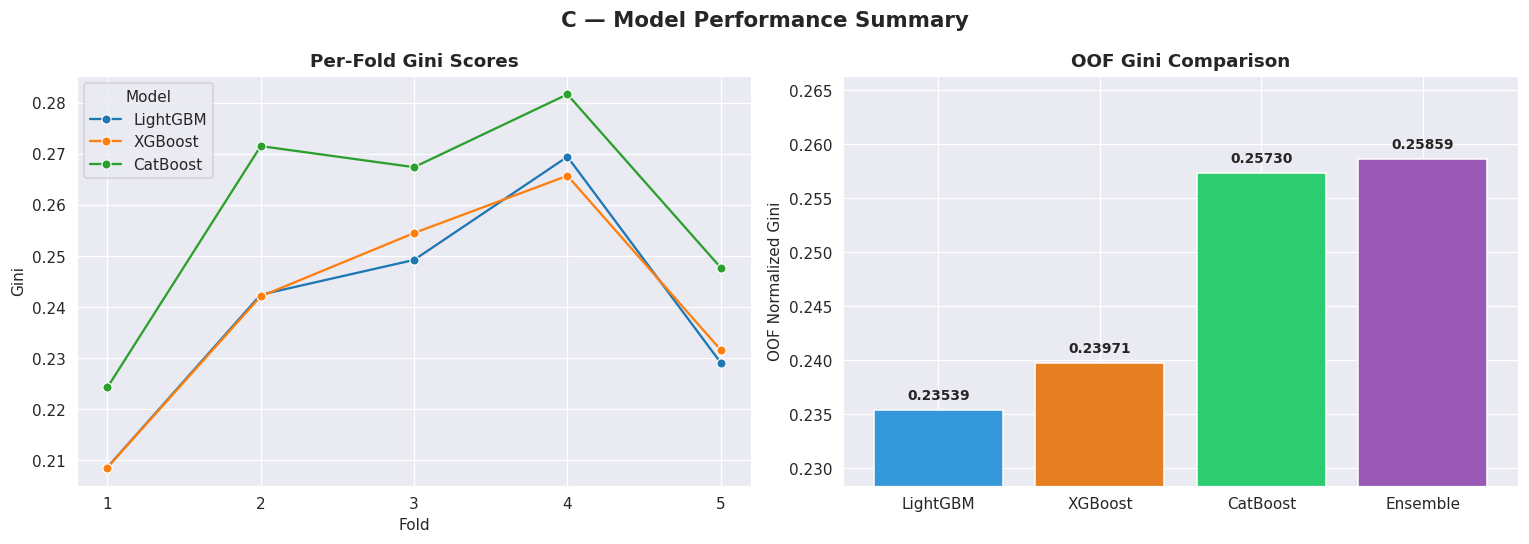

In [ ]:
# VISUALIZATION — Model Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fold-wise Gini comparison
fold_df = pd.DataFrame({
    'Fold': list(range(1, N_FOLDS+1)) * 3,
    'Model': ['LightGBM']*N_FOLDS + ['XGBoost']*N_FOLDS + ['CatBoost']*N_FOLDS,
    'Gini': lgb_gini_scores + xgb_gini_scores + cat_gini_scores
})
sns.lineplot(data=fold_df, x='Fold', y='Gini', hue='Model', marker='o', ax=axes[0])
axes[0].set_title('Per-Fold Gini Scores', fontweight='bold')
axes[0].set_xticks(range(1, N_FOLDS+1))

# OOF Gini bar chart
models   = ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble']
gini_vals = [oof_gini_lgb, oof_gini_xgb, oof_gini_cat, oof_gini_ensemble]
colors    = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
bars = axes[1].bar(models, gini_vals, color=colors, edgecolor='white')
for bar, val in zip(bars, gini_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.5f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylabel('OOF Normalized Gini')
axes[1].set_title('OOF Gini Comparison', fontweight='bold')
axes[1].set_ylim([min(gini_vals)*0.97, max(gini_vals)*1.03])

plt.suptitle('C — Model Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C_model_comparison.png', bbox_inches='tight')
plt.show()

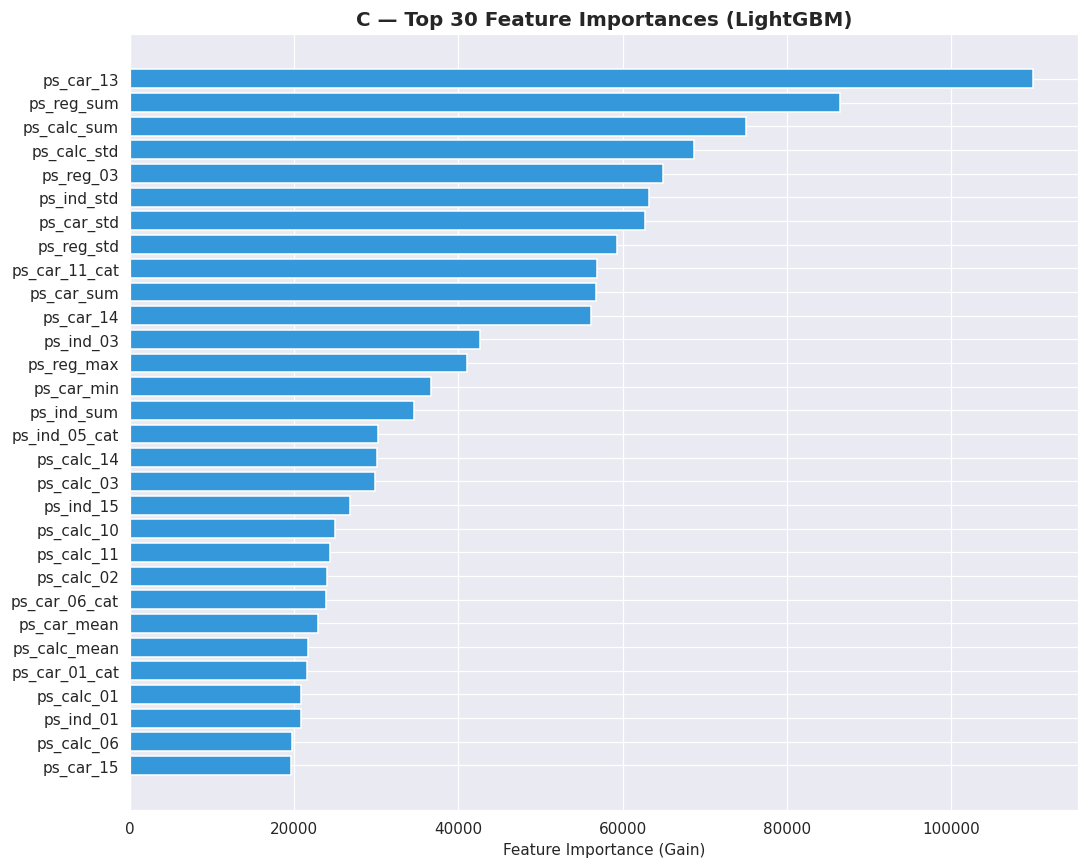

In [ ]:
# ── LightGBM Feature Importance ──────────────────────────────────────
importance_df = pd.DataFrame({
    'feature': all_feats,
    'importance': lgb_models[-1].feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color='#3498db', edgecolor='white')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('C — Top 30 Feature Importances (LightGBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# GENERATING SUBMISSION FILE

submission = pd.DataFrame({
    'id': test['id'],
    'target': pred_ensemble
})

submission.to_csv(SUB_PATH, index=False)
print(f'Submission saved: {SUB_PATH}')
print(f'Shape: {submission.shape}')
print(f'Prediction range: [{submission.target.min():.4f}, {submission.target.max():.4f}]')
submission.head()

Submission saved: /content/drive/MyDrive/cassandra/veritas_submission_cass.csv
Shape: (178564, 2)
Prediction range: [0.1377, 0.8070]


,id,target
0,1,0.389199
1,2,0.597396
2,3,0.349107
3,4,0.332955
4,5,0.398009


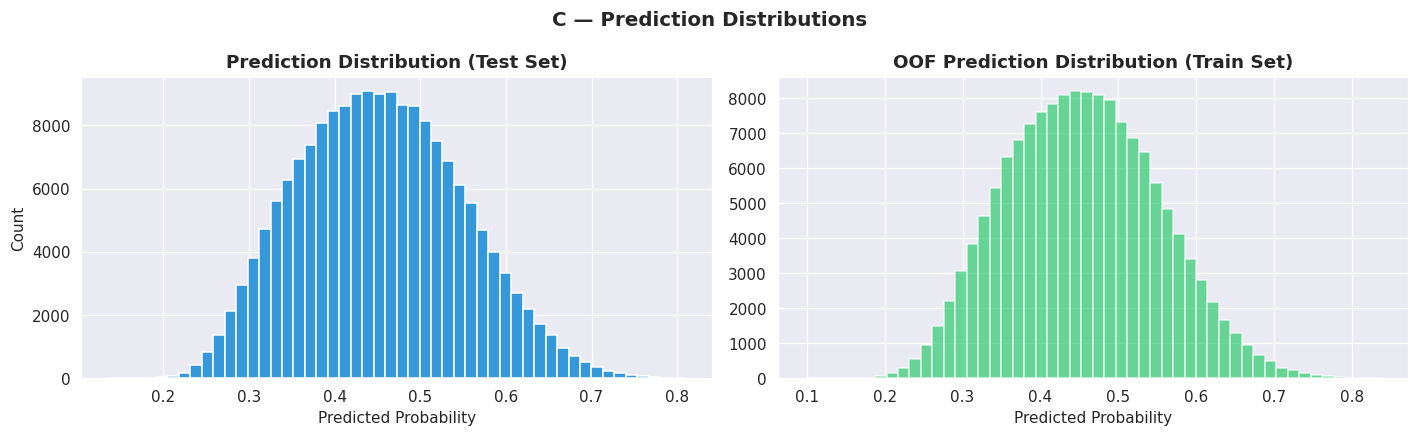


 DONE — All outputs saved to Drive.

 FINAL OOF NORMALIZED GINI: 0.25859


In [ ]:
# ── Prediction Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(pred_ensemble, bins=50, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Distribution (Test Set)', fontweight='bold')

axes[1].hist(oof_ensemble, bins=50, color='#2ecc71', edgecolor='white', alpha=0.7, label='OOF')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_title('OOF Prediction Distribution (Train Set)', fontweight='bold')

plt.suptitle('C — Prediction Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C_predictions.png', bbox_inches='tight')
plt.show()

print('\n DONE — All outputs saved to Drive.')
print(f'\n FINAL OOF NORMALIZED GINI: {oof_gini_ensemble:.5f}')

## Pipeline Summary
| Step | Detail |
|------|--------|
| Missing values | Replace -1→NaN, impute (median/mode) + missingness flags |
| Feature engineering | Group aggregates (sum/mean/std/max/min), binary sum, total missing |
| Models | LightGBM + XGBoost + CatBoost |
| Validation | 5-fold Stratified CV |
| Metric | Normalized Gini Coefficient |
| Ensemble | Optuna-optimized weighted average |
| Class imbalance | scale_pos_weight in all models |